In [2]:
import pandas as pd 
import numpy as np 

In [3]:
df = pd.read_csv("IRIS.csv")

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.sample(8)

,sepal_length,sepal_width,petal_length,petal_width,species
33,5.5,4.2,1.4,0.2,Iris-setosa
38,4.4,3.0,1.3,0.2,Iris-setosa
65,6.7,3.1,4.4,1.4,Iris-versicolor
96,5.7,2.9,4.2,1.3,Iris-versicolor
87,6.3,2.3,4.4,1.3,Iris-versicolor
138,6.0,3.0,4.8,1.8,Iris-virginica
121,5.6,2.8,4.9,2.0,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica


In [6]:
df.shape

(150, 5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [8]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 3


In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(147, 5)

In [13]:
df.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
148,6.2,3.4,5.4,2.3,Iris-virginica
21,5.1,3.7,1.5,0.4,Iris-setosa
35,5.0,3.2,1.2,0.2,Iris-setosa
143,6.8,3.2,5.9,2.3,Iris-virginica
117,7.7,3.8,6.7,2.2,Iris-virginica
104,6.5,3.0,5.8,2.2,Iris-virginica
4,5.0,3.6,1.4,0.2,Iris-setosa
26,5.0,3.4,1.6,0.4,Iris-setosa
86,6.7,3.1,4.7,1.5,Iris-versicolor
17,5.1,3.5,1.4,0.3,Iris-setosa


In [14]:
X = df.iloc[:,:-1]
Y = df["species"]

In [15]:
print(df.shape)
print(X.shape)
print(Y.shape)

(147, 5)
(147, 4)
(147,)


In [35]:
X = df.iloc[:, :-1]
Y = df["species"]

print("df shape:", df.shape)
print("X shape:", X.shape)
print("Y shape:", Y.shape)

df shape: (147, 5)
X shape: (147, 4)
Y shape: (147,)


In [17]:
# X.head()
Y.shape

(147,)

In [36]:
print("Unique species:")
print(Y.unique())

Unique species:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [37]:
print("Number of classes:", Y.nunique())

Number of classes: 3


In [38]:
# Class distribution

print(Y.value_counts())

species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64


In [21]:
# Class distribution as percentages

print(Y.value_counts(normalize=True) * 100)

species
Iris-versicolor    34.013605
Iris-virginica     33.333333
Iris-setosa        32.653061
Name: proportion, dtype: float64


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

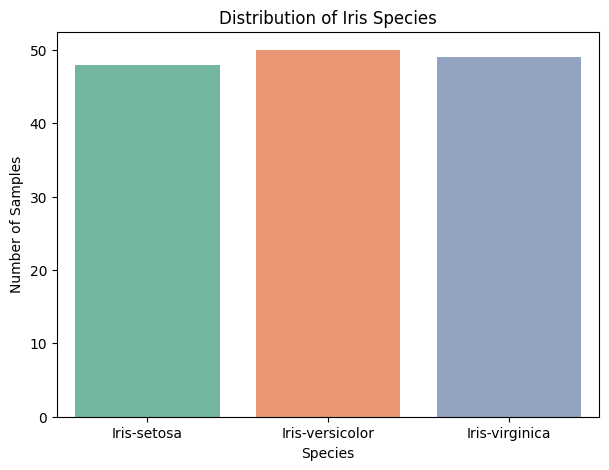

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=Y,
    hue=Y,
    palette="Set2",
    legend=False
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")

plt.show()

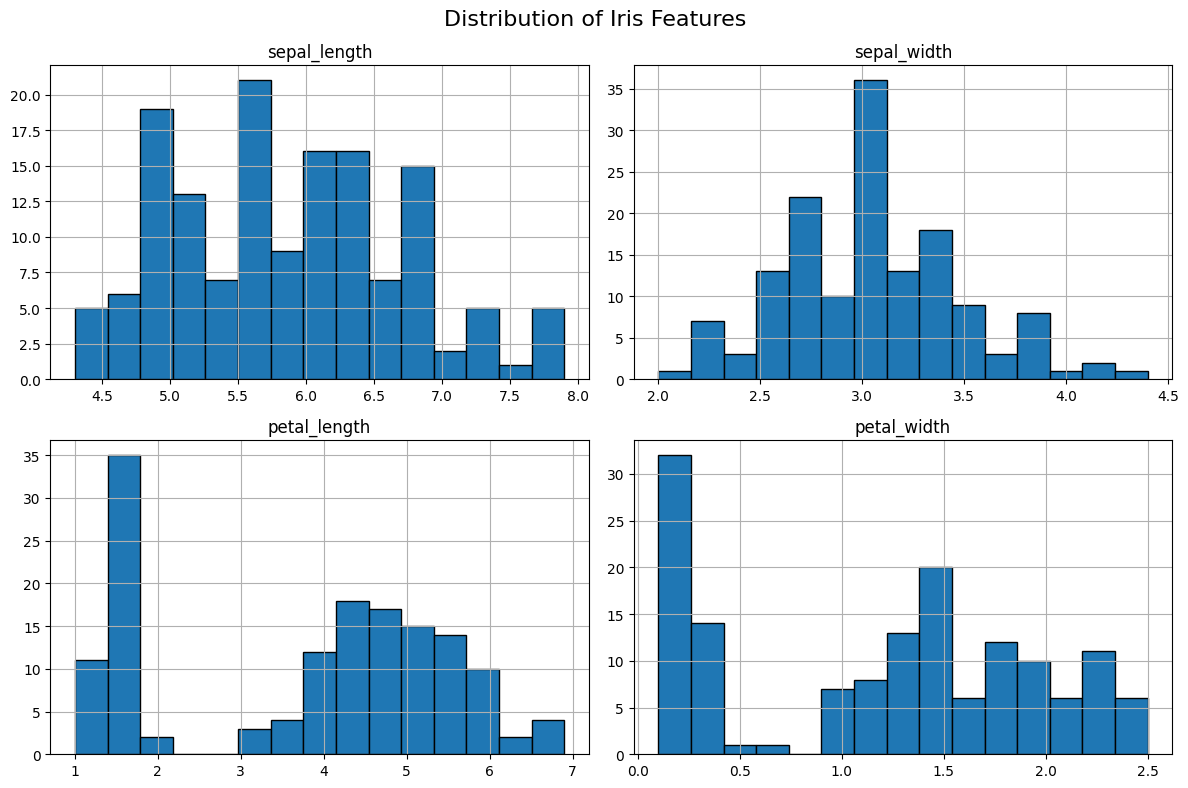

In [24]:
X.hist(
    figsize=(12, 8),
    bins=15,
    edgecolor="black"
)

plt.suptitle("Distribution of Iris Features", fontsize=16)
plt.tight_layout()
plt.show()

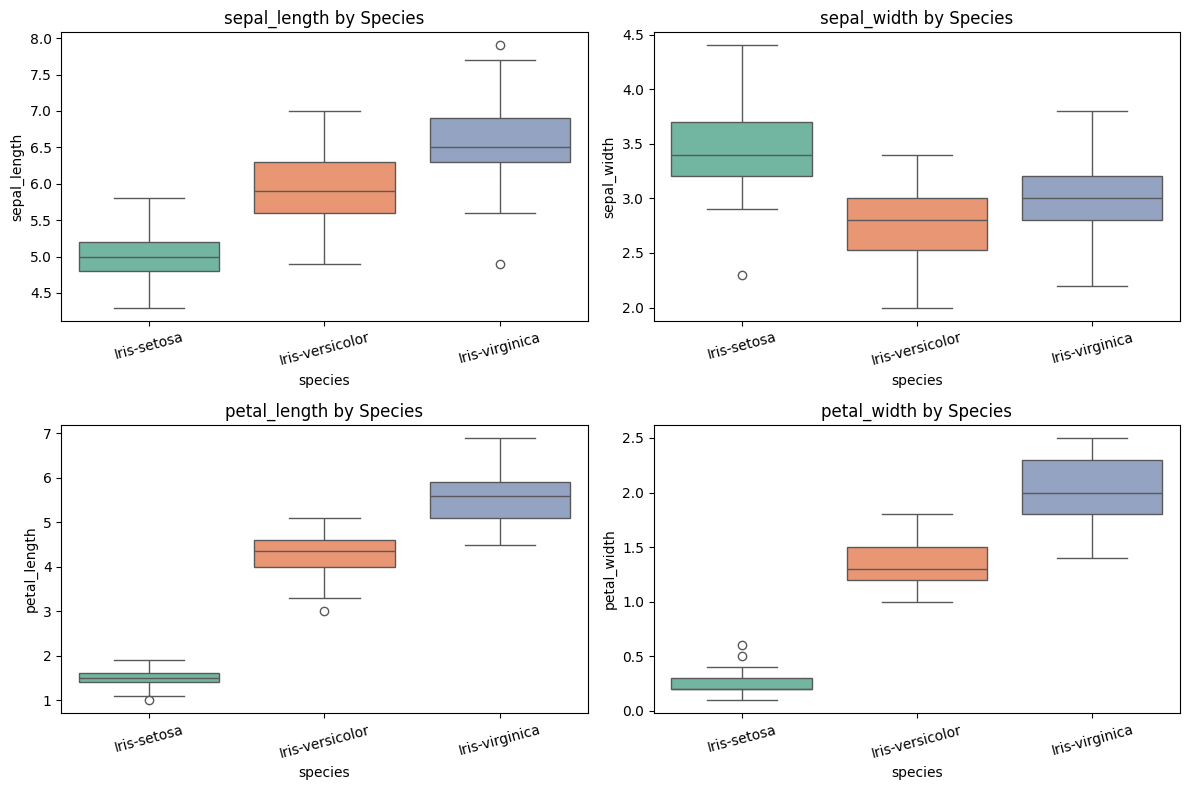

In [25]:
plt.figure(figsize=(12, 8))

for i, X in enumerate(X, 1):
    plt.subplot(2, 2, i)

    sns.boxplot(
        data=df,
        x=Y,
        y=X,
        hue=Y,
        palette="Set2",
        legend=False
    )

    plt.title(f"{X} by Species")
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## Observation

The pairplot shows how the three iris species are distributed across the
different feature combinations.

Petal length and petal width generally provide strong separation between
the species. Setosa is particularly well separated, while Versicolor and
Virginica show some overlap.

Therefore, petal-related features are expected to be highly useful for
classification.

## Train-Test Split

We divide the dataset into:

- 80% training data
- 20% testing data

The training set is used to train the models, while the test set is used
to evaluate their performance on unseen data.

In [28]:
from sklearn.model_selection import train_test_split

In [40]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size= 0.20, random_state= 42)

In [41]:
print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (147, 4)
Y shape: (147,)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 117
Testing samples: 30


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score
)

import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [44]:
scaler = StandardScaler()

In [45]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)

print("k-NN Accuracy:",
      accuracy_score(y_test, knn_predictions))

k-NN Accuracy: 0.9333333333333333


In [46]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, logistic_predictions)
)

Logistic Regression Accuracy: 0.9333333333333333


In [47]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test, tree_predictions)
)

Decision Tree Accuracy: 0.9333333333333333


In [48]:
results = pd.DataFrame({
    "Model": [
        "k-NN",
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, knn_predictions),
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, tree_predictions)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,k-NN,0.933333
1,Logistic Regression,0.933333
2,Decision Tree,0.933333


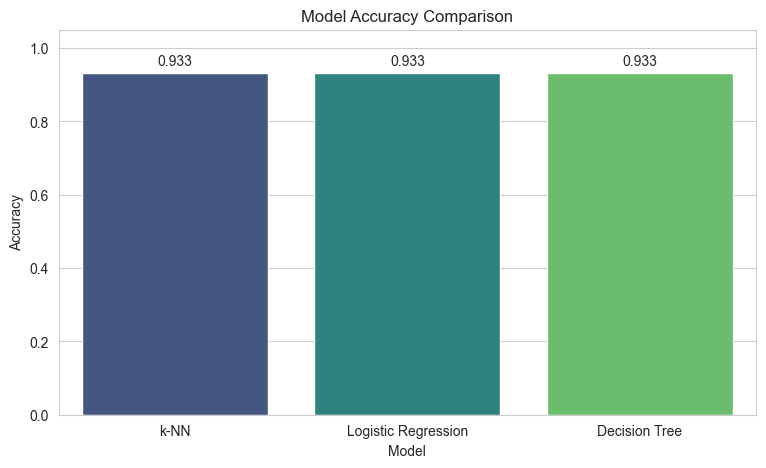

In [51]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.ylim(0, 1.05)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

for i, value in enumerate(results["Accuracy"]):
    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.show()

In [52]:
model_predictions = {
    "k-NN": knn_predictions,
    "Logistic Regression": logistic_predictions,
    "Decision Tree": tree_predictions
}

metrics = []

for model_name, predictions in model_predictions.items():

    metrics.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )
    })

metrics_df = pd.DataFrame(metrics)

metrics_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall
0,k-NN,0.933333,0.944444,0.933333
1,Logistic Regression,0.933333,0.933333,0.933333
2,Decision Tree,0.933333,0.933333,0.933333


In [61]:
models = {
    "k-NN": knn_model,
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model
}

best_model = models[best_model_name]

print("Best model selected:", best_model_name)

Best model selected: k-NN


In [59]:
best_model_name = metrics_df.loc[
    metrics_df["Accuracy"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: k-NN


In [62]:
model_filename = "iris_best_model.joblib"

joblib.dump(
    best_model,
    model_filename
)

print(f"Best model saved as: {model_filename}")

Best model saved as: iris_best_model.joblib


In [63]:
loaded_model = joblib.load(
    "iris_best_model.joblib"
)

print("Model loaded successfully!")

Model loaded successfully!


# Conclusion

In this project, we developed a machine learning classification system
for predicting iris flower species using four classical flower
measurements:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

## Exploratory Data Analysis

The EDA showed that petal length and petal width provide strong
separation between the three iris species. The pairplot demonstrated
that Setosa is particularly easy to distinguish, while Versicolor and
Virginica have some overlap.

## Models Evaluated

Three classification algorithms were trained and compared:

1. k-Nearest Neighbors
2. Logistic Regression
3. Decision Tree

The models were evaluated using:

- Accuracy
- Precision
- Recall
- Confusion Matrix

## Best Model

The model with the highest test accuracy was selected as the final model.

The selected model was saved as:

`iris_best_model.joblib`

The saved model was then loaded and used to predict the species of a
new iris flower.

## Final Result

The experiment demonstrates that traditional machine learning algorithms
can classify the Iris dataset with very high performance using only four
simple numerical measurements.

1.  Title & Objective
2.  Install Libraries
3.  Import Libraries
4.  Load Dataset
5.  Understand Dataset
6.  Missing Values & Duplicates
7.  Define Features & Target
8.  Class Distribution
9.  Feature Distributions
10. Boxplots
11. Pairplot
12. Correlation Heatmap
13. Class Separability
14. Train-Test Split
15. Feature Scaling
16. Train k-NN
17. Train Logistic Regression
18. Train Decision Tree
19. Accuracy Comparison
20. Precision & Recall Comparison
21. Metrics Visualization
22. Select Best Model
23. Confusion Matrix
24. Classification Report
25. Final Metrics
26. Decision Tree Visualization
27. Feature Importance
28. Save Best Model
29. Load Best Model
30. Example Inference
31. Prediction Function
32. Prediction Probabilities
33. Final Results Table
34. Conclusion